In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import xticks

df = pd.read_csv('../data/cleaned_airline_reviews.csv')
df

,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Value For Money,Recommended,sentiment,label,full_text,recommended_binary
0,AB Aviation,9.0,pretty decent airline,2019-11-11,True,Moroni to Moheli. Turned out to be a pretty de...,Solo Leisure,Economy Class,Moroni to Moheli,2019-11-01,4.0,5.0,4.0,4.0,3.0,yes,positive,2,"""pretty decent airline"" Moroni to Moheli. Tu...",1
1,AB Aviation,1.0,Not a good airline,2019-06-25,True,Moroni to Anjouan. It is a very small airline....,Solo Leisure,Economy Class,Moroni to Anjouan,2019-06-01,2.0,2.0,1.0,1.0,2.0,no,negative,0,"""Not a good airline"" Moroni to Anjouan. It is...",0
2,AB Aviation,1.0,flight was fortunately short,2019-06-25,True,Anjouan to Dzaoudzi. A very small airline and ...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,2019-06-01,2.0,1.0,1.0,1.0,2.0,no,negative,0,"""flight was fortunately short"" Anjouan to Dz...",0
3,Adria Airways,1.0,I will never fly again with Adria,2019-09-28,False,Please do a favor yourself and do not fly with...,Solo Leisure,Economy Class,Frankfurt to Pristina,2019-09-01,1.0,1.0,2.0,1.0,1.0,no,negative,0,"""I will never fly again with Adria"" Please d...",0
4,Adria Airways,1.0,it ruined our last days of holidays,2019-09-24,True,Do not book a flight with this airline! My fri...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,2019-09-01,1.0,1.0,1.0,1.0,1.0,no,negative,0,"""it ruined our last days of holidays"" Do not ...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22324,ZIPAIR,1.0,customer service is terrible,2022-07-05,False,Bangkok to Tokyo. I’ve flown many low cost air...,Couple Leisure,Economy Class,Bangkok to Tokyo,2022-06-01,2.0,1.0,2.0,1.0,1.0,no,negative,0,"""customer service is terrible"" Bangkok to Tok...",0
22325,ZIPAIR,1.0,Avoid at all costs,2022-06-01,True,Avoid at all costs. I booked flights to go fro...,Solo Leisure,Economy Class,Singapore to Tokyo,2022-06-01,3.0,3.0,2.0,1.0,1.0,no,negative,0,"""Avoid at all costs"" Avoid at all costs. I b...",0
22326,ZIPAIR,3.0,Will not recommend to anyone,2022-05-31,True,Flight was leaving at 23.15 and after an hour ...,Business,Economy Class,Bangkok to Tokyo,2022-05-01,2.0,4.0,2.0,1.0,2.0,no,negative,0,"""Will not recommend to anyone"" Flight was le...",0
22327,ZIPAIR,6.0,It was immaculately clean,2022-05-23,True,Zipair is JAL’s budget airline. They don’t hav...,Business,Business Class,Tokyo to Los Angeles,2022-05-01,3.0,4.0,3.0,1.0,5.0,yes,neutral,1,"""It was immaculately clean"" Zipair is JAL’s b...",1


In [19]:
df["sentiment"].value_counts(normalize=True)

sentiment
negative    0.721304
positive    0.211295
neutral     0.067401
Name: proportion, dtype: float64

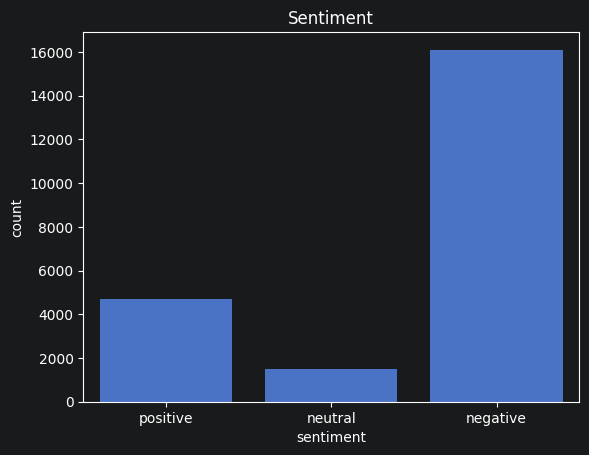

In [20]:
sns.countplot(x=df["sentiment"].sort_values(ascending=False))
plt.title('Sentiment')
plt.show()

In [23]:
airline_sentiment = df.groupby('Airline Name')['sentiment']\
    .value_counts(normalize=True)\
    .unstack()

airline_sentiment['negative'].sort_values(ascending=False)

Airline Name
flybe                1.0
ATA Airlines         1.0
Air Cote d'Ivoire    1.0
Sun-Air              1.0
Sudan Airways        1.0
                    ... 
TransAsia Airways    NaN
TransNusa            NaN
Trigana Air          NaN
Yakutia Airlines     NaN
Zambia Airways       NaN
Name: negative, Length: 497, dtype: float64

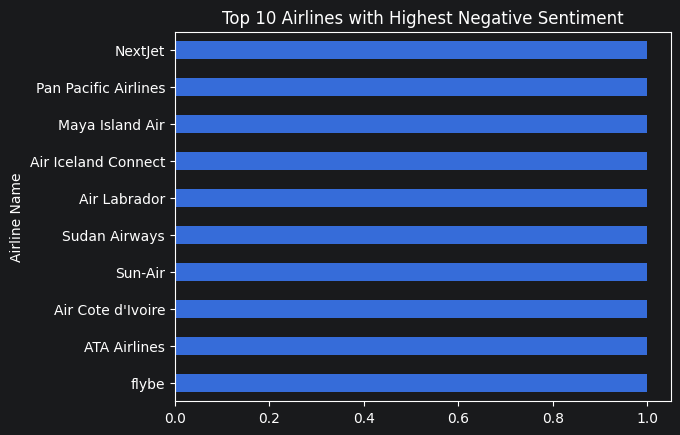

In [32]:
airline_sentiment['negative'].sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Airlines with Highest Negative Sentiment")
plt.show()

In [33]:
airline_counts = df['Airline Name'].value_counts()

# Keep airlines with at least 50 reviews
valid_airlines = airline_counts[airline_counts >= 50].index

filtered_df = df[df['Airline Name'].isin(valid_airlines)]

In [34]:
airline_sentiment = filtered_df.groupby('Airline Name')['sentiment']\
    .value_counts(normalize=True)\
    .unstack()

top_negative = airline_sentiment['negative'].sort_values(ascending=False).head(10)

top_negative

Airline Name
Viva Air             0.985714
Interjet             0.980000
Frontier Airlines    0.980000
Spirit Airlines      0.980000
Volaris              0.980000
flydubai             0.970000
Silver Airways       0.970000
Jetblue Airways      0.970000
Allegiant Air        0.970000
Swoop                0.960000
Name: negative, dtype: float64

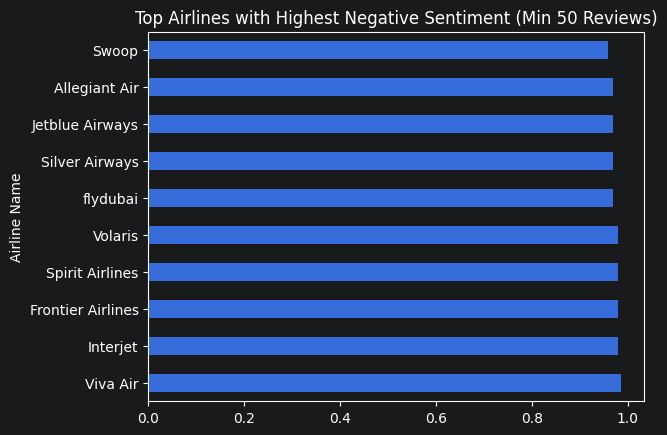

In [35]:
top_negative.plot(kind='barh')
plt.title("Top Airlines with Highest Negative Sentiment (Min 50 Reviews)")
plt.show()

In [36]:
avg_rating = filtered_df.groupby('Airline Name')['Overall_Rating'].mean()

avg_rating.sort_values().head(10)

Airline Name
Viva Air             1.20
Frontier Airlines    1.23
Spirit Airlines      1.26
Volaris              1.27
Interjet             1.28
Silver Airways       1.29
GoAir                1.42
Swoop                1.42
Allegiant Air        1.43
Jetblue Airways      1.46
Name: Overall_Rating, dtype: float64

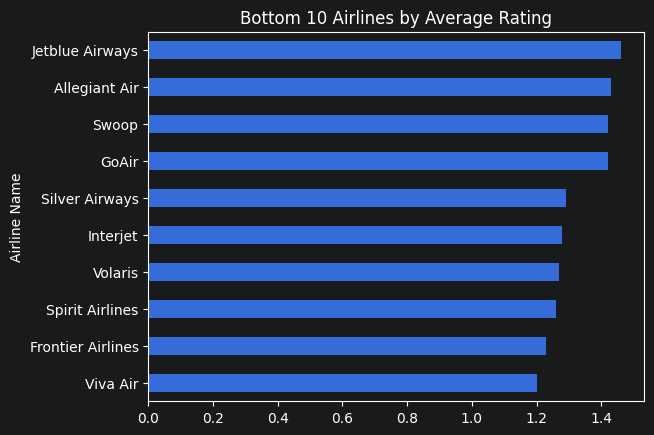

In [37]:
avg_rating.sort_values().head(10).plot(kind='barh')
plt.title("Bottom 10 Airlines by Average Rating")
plt.show()

In [39]:
from scipy.stats import spearmanr#correlation

cols = [
    'Seat Comfort',
    'Cabin Staff Service',
    'Food & Beverages',
    'Ground Service',
    'Value For Money'
]

for col in cols:
    corr, _ = spearmanr(df['Overall_Rating'], df[col])
    print(f"{col}: {corr:.2f}")

Seat Comfort: 0.39
Cabin Staff Service: 0.42
Food & Beverages: 0.34
Ground Service: 0.39
Value For Money: 0.55


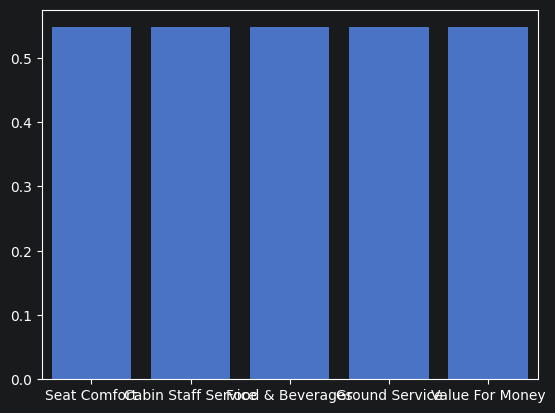

In [50]:
sns.barplot(x=cols, y=corr)
plt.show()

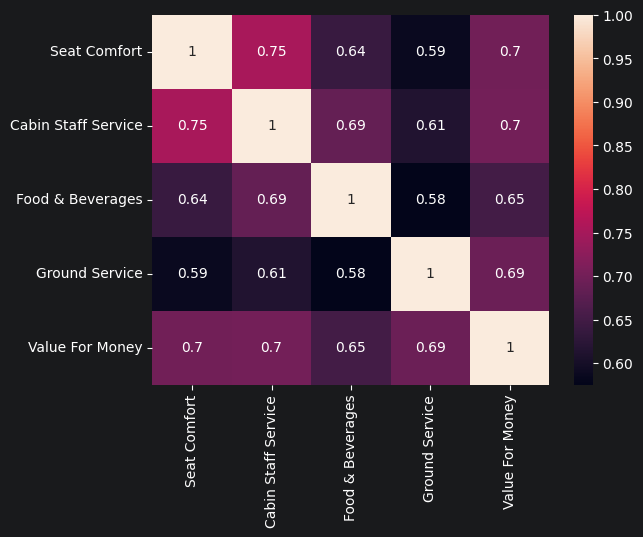

In [41]:
sns.heatmap(df[cols].corr(), annot=True)#Correlation between columns
plt.show()